In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Loading data


In [29]:
WindData = pd.read_csv('dataset_as03.csv', parse_dates = ['name'], index_col = 'name')
WindData

,Cup116m_Mean,Cup116m_Stdv,Cup116m_Min,Cup116m_Max,Cup114m_Mean,Cup114m_Stdv,Cup114m_Min,Cup114m_Max,Cup100m_Mean,Cup100m_Stdv,...,Spd_stdv,Spd_min,Spd_max,Dir,Dir_stdv,W,W_stdv,Available,CNR,Broad
name,,,,,,,,,,,,,,,,,,,,,
2015-09-07 11:00:00,2.29737,0.436317,1.018530,3.19492,2.29027,0.485124,0.857926,3.26162,2.26154,0.483488,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2015-09-07 11:10:00,2.33373,1.142690,0.540292,6.16171,2.02599,0.857467,0.522059,5.41615,2.08581,0.905685,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2015-09-07 11:20:00,2.65680,0.516193,1.161560,4.43188,2.19485,0.629905,0.861483,3.67092,2.30559,0.452007,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2015-09-07 11:30:00,2.19811,0.616147,0.622069,3.82984,2.15986,0.644860,0.522059,3.75443,2.12930,0.554329,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2015-09-07 11:40:00,2.81388,0.951594,1.138440,7.15864,2.70615,1.024040,0.950788,6.85117,2.73136,1.012010,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-11-30 23:10:00,15.83240,1.187640,12.371700,19.12550,15.86360,1.196350,12.384200,19.37910,15.61280,1.273340,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2015-11-30 23:20:00,18.25160,0.946480,15.250400,21.79970,18.32750,0.967669,15.620900,21.43100,18.22050,1.013660,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2015-11-30 23:30:00,18.61920,0.916737,15.319600,20.95830,18.68460,0.942880,15.596900,21.11640,18.52110,0.996963,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


Let's check first for outliers

In [ ]:
def clean_zero_and_flatline(df, window=6):
    """
    Replace individual values with np.nan when:
    1) Mean, Min, Max and Stdv are all zero (dead sensor)
    2) The Mean signal is flat-lined over a rolling window
    
    Parameters:
    df : pandas DataFrame
    window : int
        Number of consecutive samples defining flatline (default=6)
    
    Returns:
    Cleaned DataFrame
    """
    
    df_clean = df.copy()
    
    # Automatically detect measurement prefixes
    prefixes = set(col.rsplit('_', 1)[0] for col in df.columns)
    
    for prefix in prefixes:
        
        mean_col = f"{prefix}_Mean"
        min_col  = f"{prefix}_Min"
        max_col  = f"{prefix}_Max"
        std_col  = f"{prefix}_Stdv"
        
        # Skip if any column missing
        if not all(col in df_clean.columns for col in [mean_col, min_col, max_col, std_col]):
            continue
        
        # ---- Rule 1: All statistics equal zero ----
        zero_mask = (
            (df_clean[mean_col] == 0) &
            (df_clean[min_col]  == 0) &
            (df_clean[max_col]  == 0) &
            (df_clean[std_col]  == 0)
        )
        
        df_clean.loc[zero_mask, [mean_col, min_col, max_col, std_col]] = np.nan
        
        # ---- Rule 2: Flatline detection on Mean ----
        rolling_std = df_clean[mean_col].rolling(window).std()
        flat_mask = rolling_std == 0
        
        df_clean.loc[flat_mask, [mean_col, min_col, max_col, std_col]] = np.nan
    
    return df_clean

Plots of cup anemometeres data at 116 m

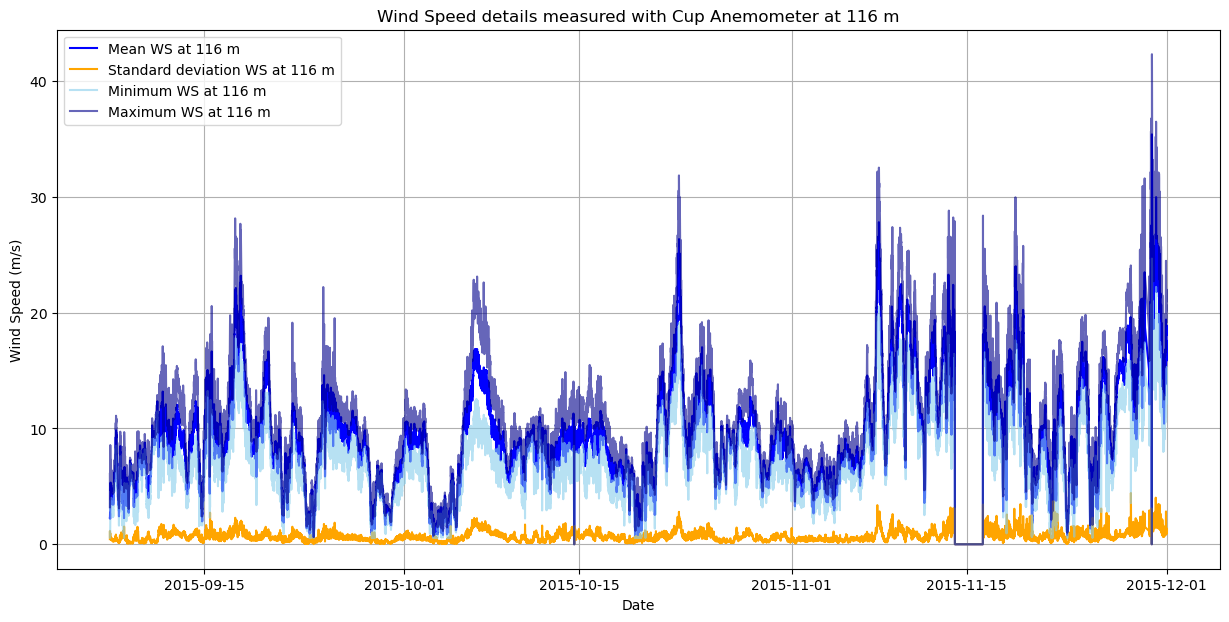

In [ ]:


plt.figure(figsize=(15, 7))
plt.plot(WindData['Cup116m_Mean'], label = 'Mean WS at 116 m', color = 'blue')
plt.plot(WindData['Cup116m_Stdv'], label = 'Standard deviation WS at 116 m', color = 'orange')
plt.plot(WindData['Cup116m_Min'], label = 'Minimum WS at 116 m', color = 'skyblue', alpha = 0.6)
plt.plot(WindData['Cup116m_Max'], label = 'Maximum WS at 116 m', color = 'darkblue', alpha = 0.6)
plt.title('Wind Speed details measured with Cup Anemometer at 116 m')
plt.xlabel('Date')
plt.ylabel('Wind Speed (m/s)')
plt.legend()
plt.grid(True)
plt.show()

Plots of cup anemometer data at 114 m

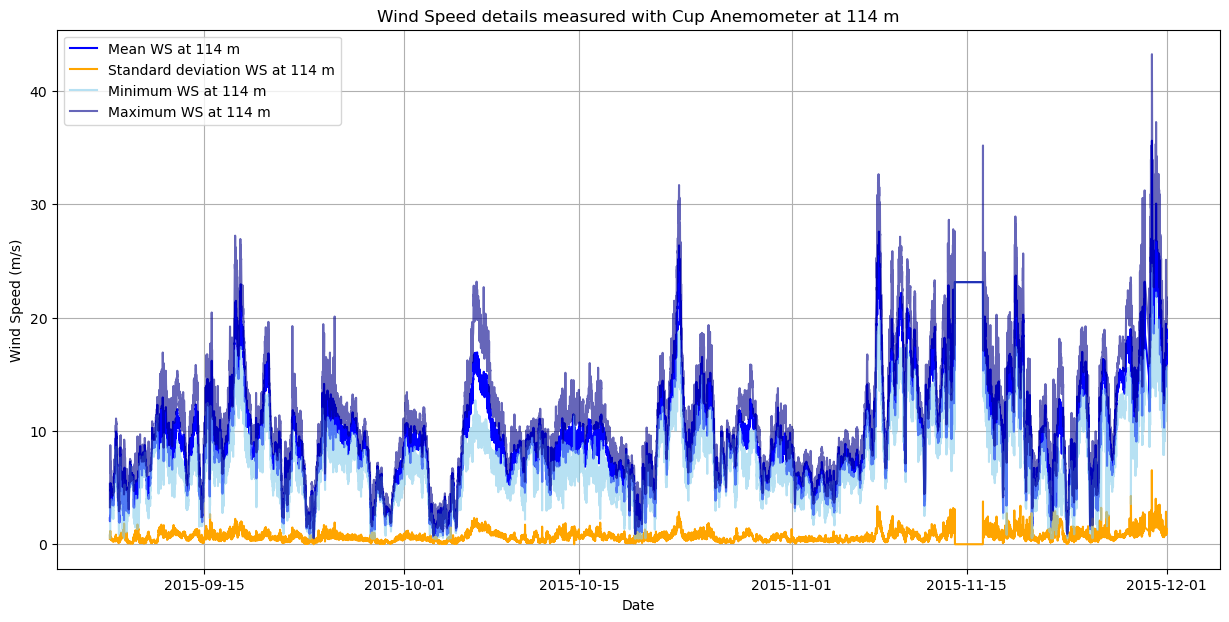

In [25]:
plt.figure(figsize=(15, 7))
plt.plot(WindData['Cup114m_Mean'], label = 'Mean WS at 114 m', color = 'blue')
plt.plot(WindData['Cup114m_Stdv'], label = 'Standard deviation WS at 114 m', color = 'orange')
plt.plot(WindData['Cup114m_Min'], label = 'Minimum WS at 114 m', color = 'skyblue', alpha = 0.6)
plt.plot(WindData['Cup114m_Max'], label = 'Maximum WS at 114 m', color = 'darkblue', alpha = 0.6)
plt.title('Wind Speed details measured with Cup Anemometer at 114 m')
plt.xlabel('Date')
plt.ylabel('Wind Speed (m/s)')
plt.legend()
plt.grid(True)
plt.show()

Plots of cup anemometer data at 100 m

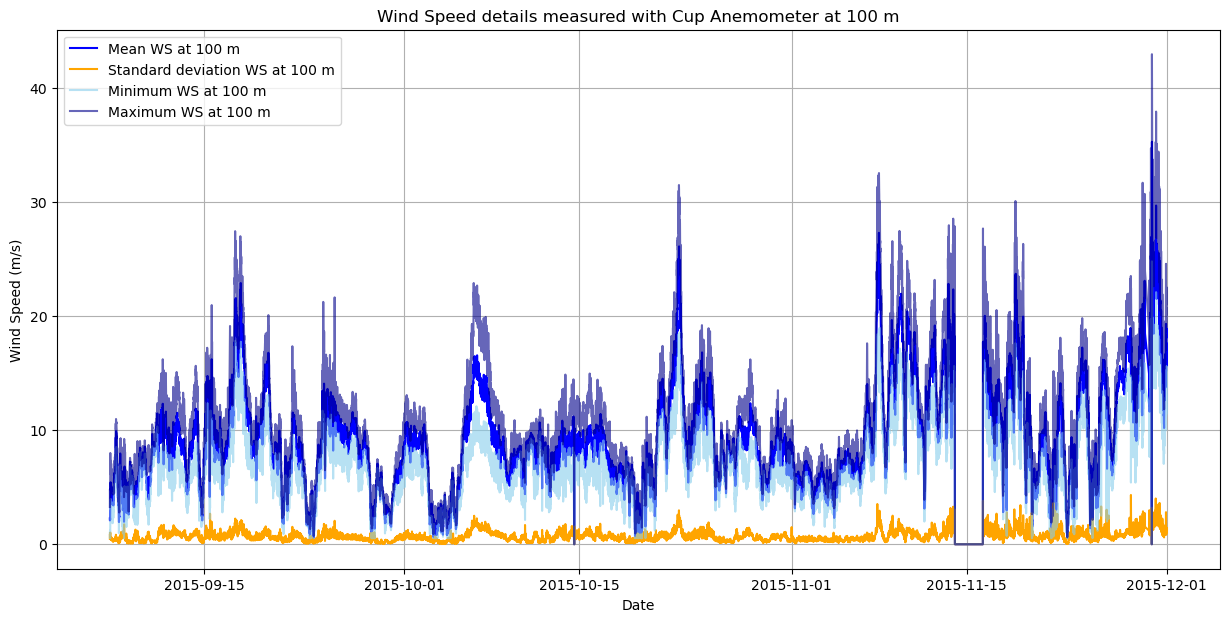

In [27]:
plt.figure(figsize=(15, 7))
plt.plot(WindData['Cup100m_Mean'], label = 'Mean WS at 100 m', color = 'blue')
plt.plot(WindData['Cup100m_Stdv'], label = 'Standard deviation WS at 100 m', color = 'orange')
plt.plot(WindData['Cup100m_Min'], label = 'Minimum WS at 100 m', color = 'skyblue', alpha = 0.6)
plt.plot(WindData['Cup100m_Max'], label = 'Maximum WS at 100 m', color = 'darkblue', alpha = 0.6)
plt.title('Wind Speed details measured with Cup Anemometer at 100 m')
plt.xlabel('Date')
plt.ylabel('Wind Speed (m/s)')
plt.legend()
plt.grid(True)
plt.show()

Plots of vane data

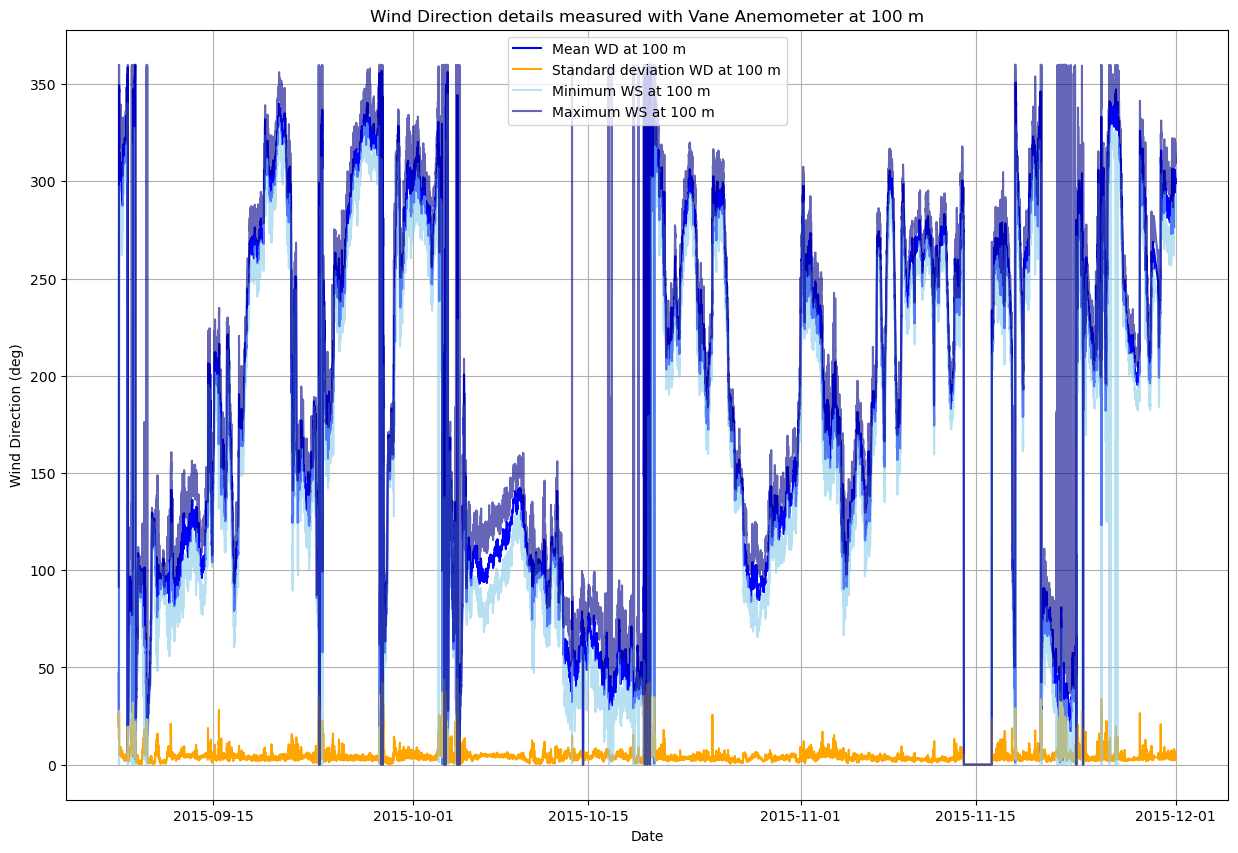

In [44]:
plt.figure(figsize=(15, 10))
plt.plot(WindData['Vane100m_Mean'], label = 'Mean WD at 100 m', color = 'blue')
plt.plot(WindData['Vane100m_Stdv'], label = 'Standard deviation WD at 100 m', color = 'orange')
plt.plot(WindData['Vane100m_Min'], label = 'Minimum WS at 100 m', color = 'skyblue', alpha = 0.6)
plt.plot(WindData['Vane100m_Max'], label = 'Maximum WS at 100 m', color = 'darkblue', alpha = 0.6)
plt.title('Wind Direction details measured with Vane Anemometer at 100 m')
plt.xlabel('Date')
plt.ylabel('Wind Direction (deg)')
plt.legend()
plt.grid(True)
plt.show()

Plots of temperature data

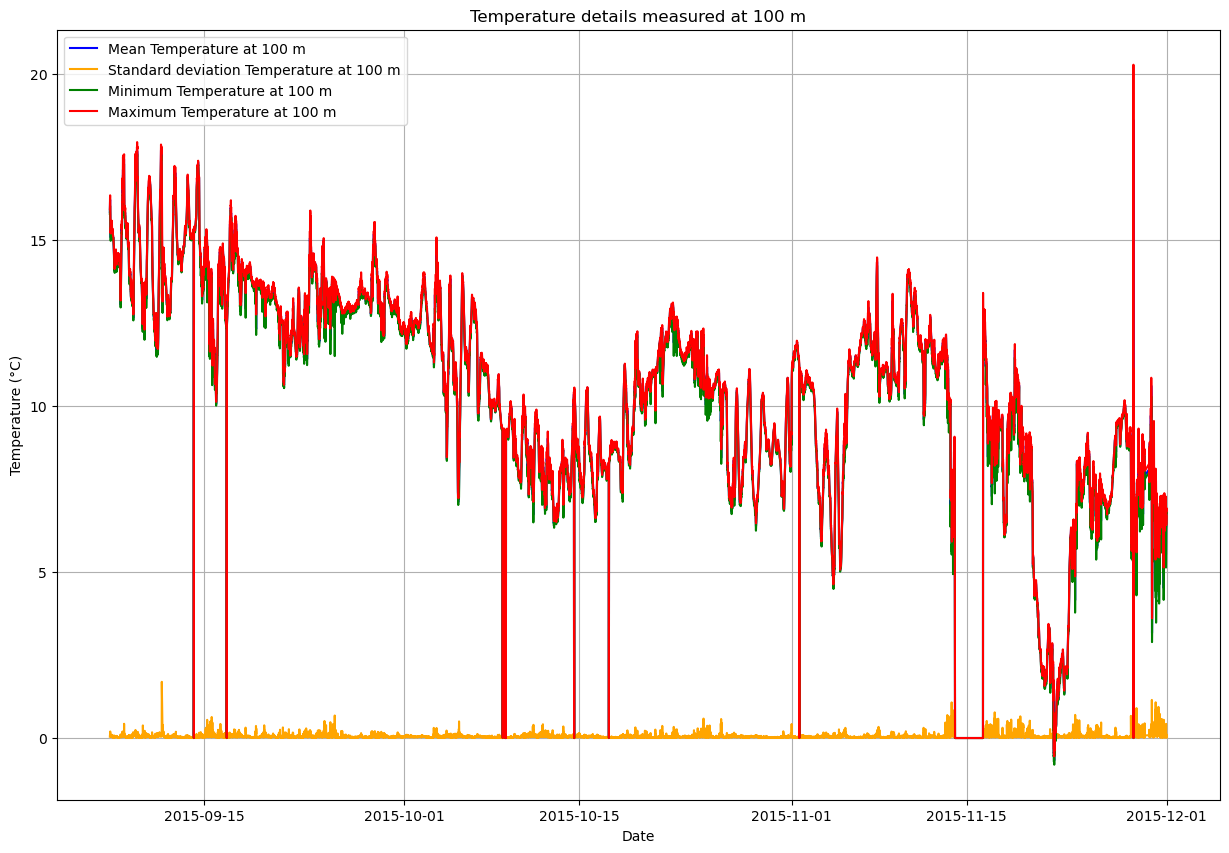

In [10]:
plt.figure(figsize=(15, 10))
plt.plot(WindData['Temp100m_Mean'], label = 'Mean Temperature at 100 m', color = 'blue')
plt.plot(WindData['Temp100m_Stdv'], label = 'Standard deviation Temperature at 100 m', color = 'orange')
plt.plot(WindData['Temp100m_Min'], label = 'Minimum Temperature at 100 m', color = 'green')
plt.plot(WindData['Temp100m_Max'], label = 'Maximum Temperature at 100 m', color = 'red')
plt.title('Temperature details measured at 100 m')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

Plots of sonic data


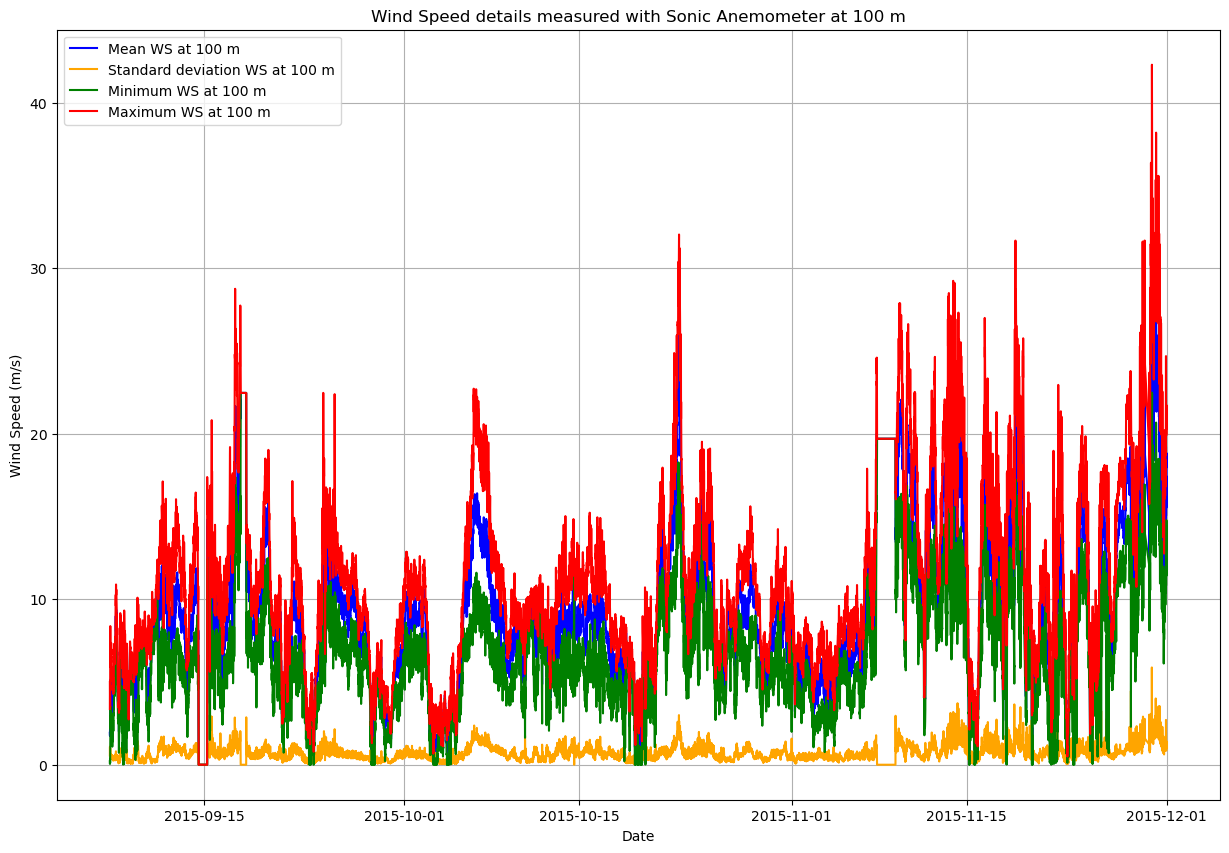

In [11]:
plt.figure(figsize=(15, 10))
plt.plot(WindData['Sonic100m_Scalar_Mean'], label = 'Mean WS at 100 m', color = 'blue')
plt.plot(WindData['Sonic100m_Scalar_Stdv'], label = 'Standard deviation WS at 100 m', color = 'orange')
plt.plot(WindData['Sonic100m_Scalar_Min'], label = 'Minimum WS at 100 m', color = 'green')
plt.plot(WindData['Sonic100m_Scalar_Max'], label = 'Maximum WS at 100 m', color = 'red')
plt.title('Wind Speed details measured with Sonic Anemometer at 100 m')
plt.xlabel('Date')
plt.ylabel('Wind Speed (m/s)')
plt.legend()
plt.grid(True)
plt.show()

We have to check for outliers. One way could be to compare the gradient between two consectutive measurements: if their difference is 0.000, the second one is likely to be wrong. Furthermore, cup anemometer wind speeds cannot be zero.